In [1]:
# import required packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeRegressor

In [2]:
!pip install ucimlrepo

In [3]:
#Import the dataset into your code
from ucimlrepo import fetch_ucirepo

# fetch dataset
bike_sharing = fetch_ucirepo(id=275)

# data (as pandas dataframes)
X = bike_sharing.data.features
y = bike_sharing.data.targets

In [5]:
print(bike_sharing.variables)

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

In [ ]:
X.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,01-01-2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,01-01-2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,01-01-2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,01-01-2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,01-01-2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


In [6]:
X = X.iloc[:,1:] # removing the redundant dteday column

In [7]:
y.head()

,cnt
0,16
1,40
2,32
3,13
4,1


In [8]:
# Combine features and target for easier analysis
data = pd.concat([X, y], axis=1)

In [9]:
# Display first few rows
print(data.head())

# Basic info
print(data.info())

# Descriptive statistics
print(data.describe())

# Check for missing values
print(data.isnull().sum())


   season  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0       1   0     1   0        0        6           0           1  0.24   
1       1   0     1   1        0        6           0           1  0.22   
2       1   0     1   2        0        6           0           1  0.22   
3       1   0     1   3        0        6           0           1  0.24   
4       1   0     1   4        0        6           0           1  0.24   

    atemp   hum  windspeed  cnt  
0  0.2879  0.81        0.0   16  
1  0.2727  0.80        0.0   40  
2  0.2727  0.80        0.0   32  
3  0.2879  0.75        0.0   13  
4  0.2879  0.75        0.0    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      17379 non-null  int64  
 1   yr          17379 non-null  int64  
 2   mnth        17379 non-null  int64  
 3   hr          17379 non-null

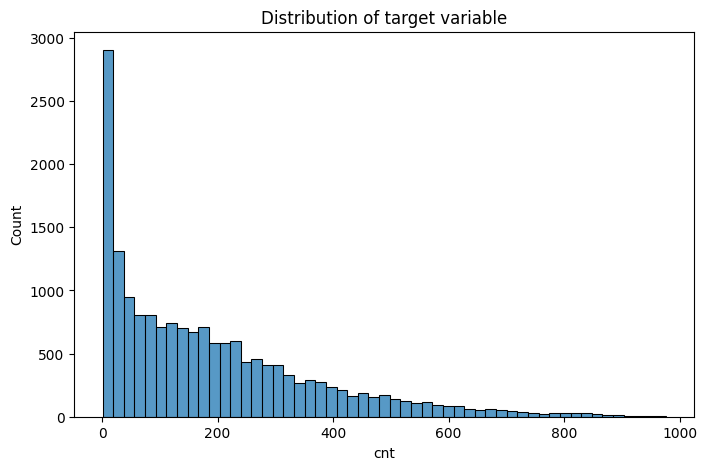

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(data=data,x='cnt')
plt.title("Distribution of target variable")
plt.show()

Decision Trees do not require feature scaling or standardization because they are based on splitting the data according to feature values, which are invariant to scaling.

# Splitting the Dataset

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [12]:
X_train = X_train.to_numpy()
X_val = X_val.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

In [13]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(12165, 12)
(2607, 12)
(2607, 12)
(12165, 1)
(2607, 1)
(2607, 1)


In [14]:
y_train = y_train.ravel()
y_val = y_val.ravel()
y_test = y_test.ravel()

# Decision Tree Regressor from scratch

In [15]:
class Node:
  def __init__(self,depth=0):
    self.feature = None # Index of feature used for splitting
    self.value = None # Predicted value at leaf nodes
    self.n_samples = None # Number of samples in this node
    self.gain = None # Reduction in impurity from this split
    self.left = None # Left subtree
    self.right = None # Right subtree
    self.threshold = None # Threshold for splitting
    self.depth = depth # Depth of the current node


class CART:
    def __init__(self, criterion='mse', max_depth=10, min_samples_split=7, min_samples_leaf=2):

        self.root = None # Root node of the tree
        self.criterion = criterion # Criterion for splitting (here MSE)
        self.max_depth = max_depth # Maximum depth allowed
        self.min_samples_split = min_samples_split # Minimum samples to allow a split
        self.min_samples_leaf = min_samples_leaf # Minimum number of samples for a leaf node

    def fit(self, features, target):
        # Fit the decision tree to the given data
        self.root = self._grow_tree(features, target, depth=0)

    def _grow_tree(self, features, target, depth):
        node = Node(depth=depth)
        node.n_samples = len(target)

        # stopping condition
        if (node.n_samples < self.min_samples_split) or (depth >= self.max_depth) or len(np.unique(target)) == 1 or (node.n_samples <= self.min_samples_leaf):
            node.value = np.mean(target) # stop and make a leaf node
            return node

        best_gain = 0.0
        best_feature = None
        best_threshold = None

        for col in range(features.shape[1]): # loop over each feature
            values = np.unique(features[:, col]) # unique values in that column
            if len(values) <= 1: # cannot split if only 1 unique value
                continue

            # finding the best threshold for discretizing the numerical values
            thresholds = (values[:-1] + values[1:]) / 2.0 # midpoints between 2 consecutive unique values
            for thr in thresholds:
                left_idx = (features[:, col] <= thr)
                right_idx = (features[:, col] > thr)

                # min_samples_leaf condition must be satisfied
                if left_idx.sum() < self.min_samples_leaf or right_idx.sum() < self.min_samples_leaf: # each child must have at least min_samples_leaf
                    continue

                # in this case, prediction = mean of target values in that node
                # so, mse for predicted y, is same as the variance about mean
                gain = self._variance_reduction(target, left_idx, right_idx)
                if gain > best_gain: # larger gain = better split
                    best_gain = gain
                    best_feature = col
                    best_threshold = thr

        # if no good split, make a leaf node  and predict mean
        if best_gain == 0.0 or best_feature is None:
            node.value = np.mean(target)
            return node

        # otherwise, use the best split and recurse to grow tree
        node.feature = best_feature
        node.threshold = best_threshold
        node.gain = best_gain

        # Splitting based on the best threshold
        left_idx = features[:,best_feature] <= best_threshold
        right_idx = features[:,best_feature] > best_threshold

        node.left = self._grow_tree(features[left_idx], target[left_idx], depth + 1)
        node.right = self._grow_tree(features[right_idx], target[right_idx], depth + 1)

        return node

    def _variance_reduction(self, target, left_idx, right_idx):
        var_total = np.var(target) * len(target) # mse (here, equal to variance) is the impurity measure and we are taking weighted impurity
        var_left = np.var(target[left_idx]) * left_idx.sum()
        var_right = np.var(target[right_idx]) * right_idx.sum()
        return var_total - (var_left + var_right)

    def predict(self, X):
        return np.array([self._predict_sample(x, self.root) for x in X])

    def _predict_sample(self, x, node):
        if node.feature is None or (node.left is None and node.right is None): # for leaf node, return node value
            return node.value
        if x[node.feature] <= node.threshold: # else, compare to node thresholds, until you hit a leaf
            return self._predict_sample(x, node.left)
        else:
            return self._predict_sample(x, node.right)


# Hyperparameter Tuning from Scratch

In [16]:
best_params = None
best_mse = float('inf')

for depth in range(10, 19):
    for min_split in range(7, 13):
        for min_leaf in range(2, 8):
            model = CART(max_depth=depth, min_samples_split=min_split, min_samples_leaf=min_leaf)
            model.fit(X_train, y_train)
            preds = model.predict(X_val)
            mse = mean_squared_error(y_val, preds)

            # updating best parameters based on mse
            if mse < best_mse:
                best_mse = mse
                best_params = (depth, min_split, min_leaf)

print("Best params:", best_params)
print("Validation MSE:", best_mse)


Best params: (16, 12, 3)
Validation MSE: 2827.11770401683


# Performance of Scratch Implementation of Decision Tree Regressor using best parameters obtained from Hyperparameter Tuning

In [17]:
best_model = CART(max_depth=best_params[0],min_samples_split=best_params[1],min_samples_leaf=best_params[2])
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

In [18]:
print("MSE:",mean_squared_error(y_test, y_pred))
print("MAE:",mean_absolute_error(y_test, y_pred))
print("R2 score:",r2_score(y_test, y_pred))

MSE: 2793.8225638497784
MAE: 31.292194545036633
R2 score: 0.9093042156370732


# MSE obtained and Scatter plot of predictions vs Ground Truths

In [19]:
print("MSE obtained on test set from the scratch implementation of Decision Tree Regressor:",mean_squared_error(y_test, y_pred))

MSE obtained on test set from the scratch implementation of Decision Tree Regressor: 2793.8225638497784


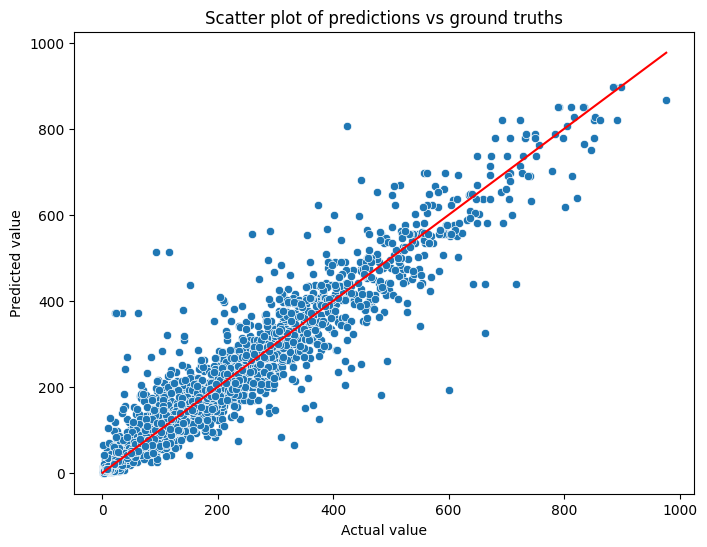

In [20]:
# Scatter plot of predictions vs ground truths
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r')
plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title("Scatter plot of predictions vs ground truths")
plt.show()

# Scikit learn implementation of Decision Tree Regressor

In [21]:
regressor_sklearn = DecisionTreeRegressor(max_depth=best_params[0],min_samples_split=best_params[1],min_samples_leaf=best_params[2])
regressor_sklearn.fit(X_train, y_train)
y_pred_sklearn = regressor_sklearn.predict(X_test)

In [22]:
print("MSE:",mean_squared_error(y_test, y_pred_sklearn))
print("MAE:",mean_absolute_error(y_test, y_pred_sklearn))
print("R2 score:",r2_score(y_test, y_pred_sklearn))

MSE: 2792.9882711504715
MAE: 31.314090943400235
R2 score: 0.9093312992578195


Cross validation

In [23]:
def cross_validate(depth, min_split, min_leaf, features, target, k_folds=5):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    mse = []

    for train_index, val_index in kf.split(features):
        X_train, X_val = features[train_index], features[val_index]
        y_train, y_val = target[train_index], target[val_index]

        # Initialize the CART tree with the given depth
        tree = DecisionTreeRegressor(max_depth = depth, min_samples_split=min_split, min_samples_leaf=min_leaf)
        tree.fit(X_train, y_train)
        y_pred = tree.predict(X_val)

        # Compute mean squared error
        error = mean_squared_error(y_val, y_pred)
        mse.append(error)

    return np.mean(mse)

In [24]:
depths = [i for i in range(10,19)]
min_splits = [i for i in range(7,13)]
min_leaves = [i for i in range(2,8)]

best_depth = None
best_splits = None
best_leaves = None
best_score = float('inf')
scores = [] # Store scores for plotting

for depth in depths:
  for min_split in min_splits:
    for min_leaf in min_leaves:
      score = cross_validate(depth,min_split,min_leaf,X_train, y_train)
      scores.append(score) # Add score to the list
      print(f"Parameters: Depth: {depth}, Min_Samples_Split: {min_split}, Min_Samples_Leaves: {min_leaf}, MSE: {score}")

      if score < best_score:
          best_score = score
          best_depth = depth
          best_splits = min_split
          best_leaves = min_leaf

print(f"Best Parameters: MaxDepth: {best_depth}, Min_Samples_Split: {best_splits}, Min_Samples_Leaves: {best_leaves} with Score: {best_score}")


Parameters: Depth: 10, Min_Samples_Split: 7, Min_Samples_Leaves: 2, MSE: 3884.270077836839
Parameters: Depth: 10, Min_Samples_Split: 7, Min_Samples_Leaves: 3, MSE: 3898.808331342704
Parameters: Depth: 10, Min_Samples_Split: 7, Min_Samples_Leaves: 4, MSE: 3847.070391686025
Parameters: Depth: 10, Min_Samples_Split: 7, Min_Samples_Leaves: 5, MSE: 3819.077142938963
Parameters: Depth: 10, Min_Samples_Split: 7, Min_Samples_Leaves: 6, MSE: 3890.826893601021
Parameters: Depth: 10, Min_Samples_Split: 7, Min_Samples_Leaves: 7, MSE: 3879.1331162040456
Parameters: Depth: 10, Min_Samples_Split: 8, Min_Samples_Leaves: 2, MSE: 3910.61226550041
Parameters: Depth: 10, Min_Samples_Split: 8, Min_Samples_Leaves: 3, MSE: 3892.940139065312
Parameters: Depth: 10, Min_Samples_Split: 8, Min_Samples_Leaves: 4, MSE: 3856.2227379104506
Parameters: Depth: 10, Min_Samples_Split: 8, Min_Samples_Leaves: 5, MSE: 3823.175798050432
Parameters: Depth: 10, Min_Samples_Split: 8, Min_Samples_Leaves: 6, MSE: 3886.12555807303

# Evaluating performance of Scikit learn implementation of Decision Tree Regressor from the hyperparameters obtained from cross validation

In [25]:
best_model_cross_val = DecisionTreeRegressor(max_depth=best_depth, min_samples_split=best_splits, min_samples_leaf=best_leaves)
best_model_cross_val.fit(X_train, y_train)
y_pred_cross_val = best_model_cross_val.predict(X_test)

In [26]:
print("MSE:",mean_squared_error(y_test, y_pred_cross_val))
print("MAE:",mean_absolute_error(y_test, y_pred_cross_val))
print("R2 score:",r2_score(y_test, y_pred_cross_val))

MSE: 2780.975725210436
MAE: 31.383955814340478
R2 score: 0.9097212622033282


# MSE from Scikit learn implementation and Scatter Plot of Predictions vs Ground level

In [27]:
print("MSE obtained on test set from the scikit learn implementation of Decision Tree Regressor:",mean_squared_error(y_test, y_pred_cross_val))

MSE obtained on test set from the scikit learn implementation of Decision Tree Regressor: 2780.975725210436


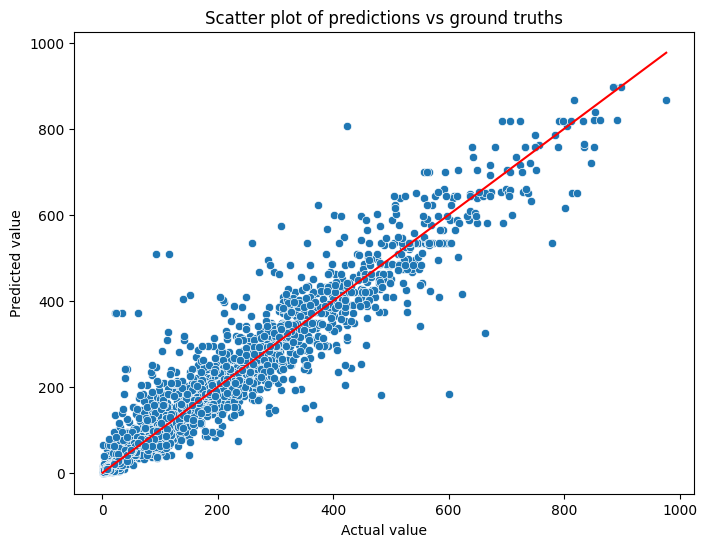

In [28]:
# Scatter plot of predictions vs ground truths
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_cross_val)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r')
plt.xlabel("Actual value")
plt.ylabel("Predicted value")
plt.title("Scatter plot of predictions vs ground truths")
plt.show()

# Visualize the decision tree regressor learned by scikit learn

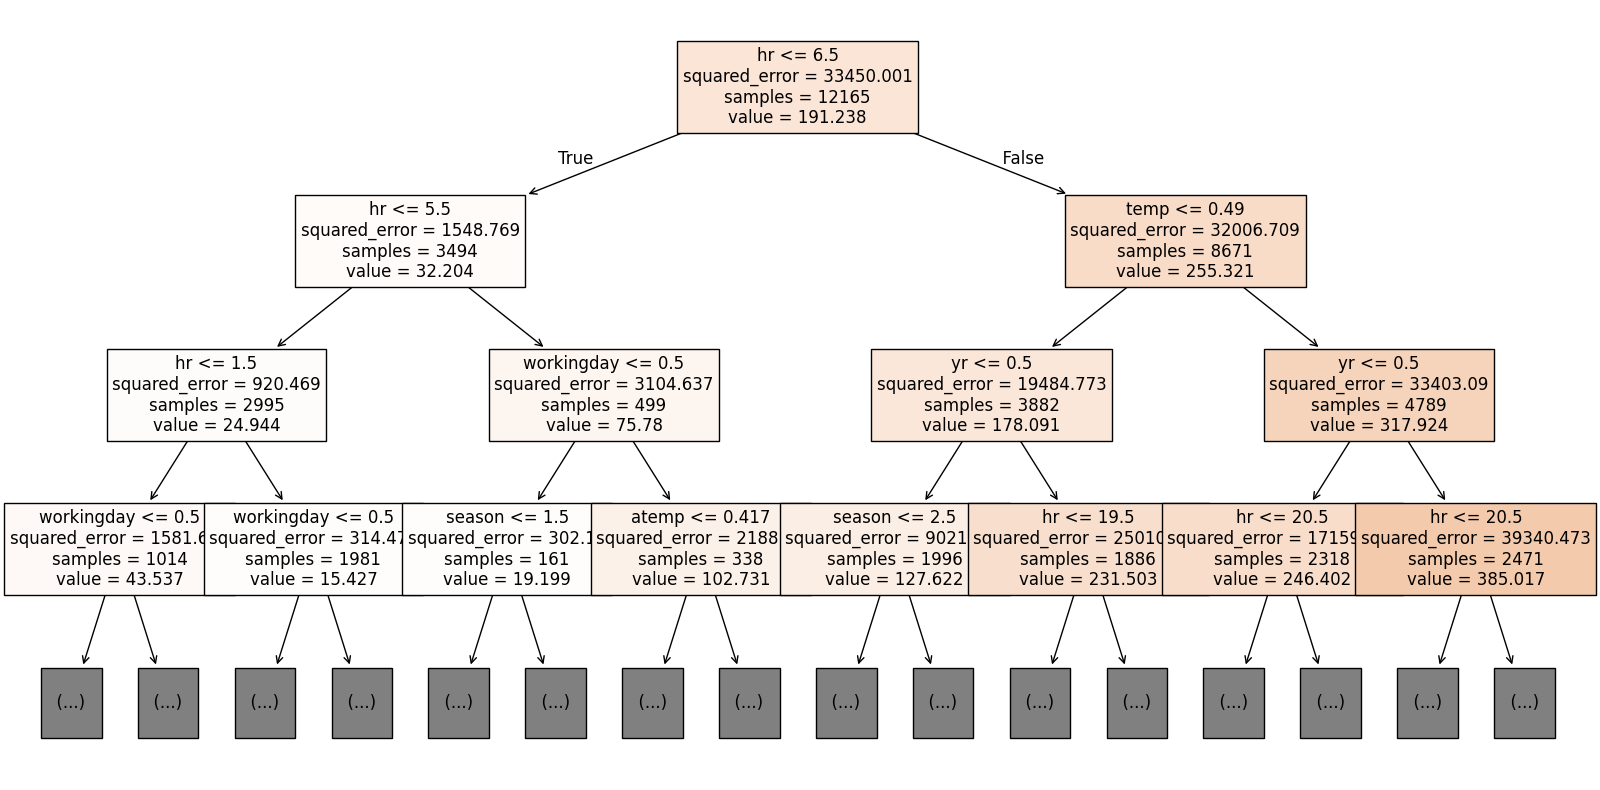

In [29]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(best_model_cross_val, max_depth=3,filled=True,feature_names=X.columns, fontsize=12) # plotting only top 3 depths
plt.show()